In [11]:
from helper import build_model, create_generators

In [36]:
import pandas as pd
train_df3 = pd.read_csv('csv_data/corrected_df2.csv')
val_df3 = pd.read_csv('csv_data/corrected_val_df3.csv')
train_df3 = train_df3.loc[:, ~train_df3.columns.str.contains('Unnamed', case=False)]
val_df3

,filepath,filename,label,source,subfolder,hash,label_idx
0,/data/FMD_DATASET/without_mask/simple/simple38...,simple3891.jpg,without_mask,dataset1_kaggle,simple,318f9ce6a041256013e957bc80882de6,1
1,/data/face_data/incorrect_mask/2127.jpg,2127.jpg,mask_worn_incorrectly,dataset2_kaggle,incorrect_mask,f6551c163c83b210aa3a57bccb9eb29f,2
2,/data/cifar_not_related/cifar_1663.jpg,cifar_1663.jpg,not_related,dataset3_cifar10,cifar_not_related,fce15d9b6089fdd635053ac509cef748,3
3,/data/FMD_DATASET/incorrect_mask/mmc/1007.jpg,1007.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,05c6c4832c40a913eb90c70822bd5336,2
4,/data/FMD_DATASET/without_mask/complex/complex...,complex282.jpg,without_mask,dataset1_kaggle,complex,993102aa24b83d3a4b34677568d2e69a,1
...,...,...,...,...,...,...,...
2724,/data/FMD_DATASET/with_mask/simple/simple2636.jpg,simple2636.jpg,with_mask,dataset1_kaggle,simple,768f82b5718a892b8e83878862a5760e,0
2725,/data/FMD_DATASET/incorrect_mask/mmc/2020.jpg,2020.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,77c4ae8a7154666b00ac003d6f25835c,2
2726,/data/cifar_not_related/cifar_0202.jpg,cifar_0202.jpg,not_related,dataset3_cifar10,cifar_not_related,e833a6e3c203d0574398c726bfdc35fb,3
2727,/data/FMD_DATASET/incorrect_mask/mc/2215.jpg,2215.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,2105748077a905c7a01c9c4305ea0aa3,2


In [39]:
train_df3

,filepath,filename,label,source,subfolder,hash,label_idx
0,data/face_data/incorrect_mask/2038.jpg,2038.jpg,mask_worn_incorrectly,dataset2_kaggle,incorrect_mask,7c2a2536faf6958c01a27fc3a7aaa86b,2
1,data/FMD_DATASET/incorrect_mask/mc/2100.jpg,2100.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,ada9e4634c1aa3c490dc9bf7ad8c67b3,2
2,data/FMD_DATASET/without_mask/simple/simple339...,simple3399.jpg,without_mask,dataset1_kaggle,simple,68aace663e9fad82ecd2c3e322043e7c,1
3,data/cifar_not_related/cifar_1093.jpg,cifar_1093.jpg,not_related,dataset3_cifar10,cifar_not_related,6508813c228951fa63add0f841aef13a,3
4,data/face_data/bare_face/1 (2585).jpg,1 (2585).jpg,without_mask,dataset2_kaggle,bare_face,bce71a9136d4d5616f3d65b090052de4,1
...,...,...,...,...,...,...,...
15499,data/FMD_DATASET/without_mask/complex/complex6...,complex610.jpg,without_mask,dataset1_kaggle,complex,80209a01a74689eddace06cc17397483,1
15500,data/cifar_not_related/cifar_2028.jpg,cifar_2028.jpg,not_related,dataset3_cifar10,cifar_not_related,a5fef687516ea6eac11384cc67e54139,3
15501,data/FMD_DATASET/without_mask/simple/simple129...,simple1298.jpg,without_mask,dataset1_kaggle,simple,fbc69356ada13c413e0be6fbdedbe24d,1
15502,data/FMD_DATASET/with_mask/simple/simple1349.jpg,simple1349.jpg,with_mask,dataset1_kaggle,simple,3afc2514b79c73e6e92ec3dea2947871,0


In [53]:
from sklearn.model_selection import train_test_split

_, validation_indices = train_test_split(
    train_df3.index, 
    test_size=0.176, 
    random_state=42
)

validation_set = train_df3.loc[validation_indices].copy()
validation_set

,filepath,filename,label,source,subfolder,hash,label_idx
10545,data/FMD_DATASET/incorrect_mask/mc/2173.jpg,2173.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,f6f76bc50ff772fc5743142320a0cbf4,2
11399,data/cifar_not_related/cifar_0039.jpg,cifar_0039.jpg,not_related,dataset3_cifar10,cifar_not_related,416f198405a2fdc1d600f27218a920b3,3
4921,data/FMD_DATASET/incorrect_mask/mc/1306.jpg,1306.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,9f542b67e959cab1dc02de1ecce80ddc,2
15252,data/face_data/incorrect_mask/2416.jpg,2416.jpg,mask_worn_incorrectly,dataset2_kaggle,incorrect_mask,9412f5b795eedfc308c17508d58922c2,2
6705,data/face_data/beard/74HNJLD7KBCY.jpg,74HNJLD7KBCY.jpg,without_mask,dataset2_kaggle,beard,5fbe5ec539605526219ee517636edb50,1
...,...,...,...,...,...,...,...
5938,data/cifar_not_related/cifar_1824.jpg,cifar_1824.jpg,not_related,dataset3_cifar10,cifar_not_related,de76a40a219b8e9b7207dff25b9bf277,3
9584,data/FMD_DATASET/with_mask/simple/simple1030.jpg,simple1030.jpg,with_mask,dataset1_kaggle,simple,bcb9958d0869be2f74cf2bdda3aa0078,0
2525,data/FMD_DATASET/with_mask/simple/simple1695.jpg,simple1695.jpg,with_mask,dataset1_kaggle,simple,4ae9ea50e59afac8f64a944944077908,0
10942,data/FMD_DATASET/with_mask/complex/complex683.jpg,complex683.jpg,with_mask,dataset1_kaggle,complex,58f15dcf03dfb81aff67a3c6e5f2852f,0


In [54]:
validation_set['label'].value_counts()


label
with_mask                712
not_related              706
mask_worn_incorrectly    657
without_mask             654
Name: count, dtype: int64

In [55]:
IMG_SIZE = (128, 128) 
BATCH_SIZE=64
NUM_CLASSES=4
LEARNING_RATE=0.0001
train_gen3, val_gen3 = create_generators(
    train_df=train_df3,
    val_df=validation_set,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_augmentation=True
)

Found 15504 validated image filenames belonging to 4 classes.
Found 2729 validated image filenames belonging to 4 classes.


In [57]:
model3=build_model( input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    dropout_rate=0.2 )

Adding a Dropout layer with rate 0.2


In [59]:
model3.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [60]:
from tensorflow.keras import callbacks
checkpoint_model3 = callbacks.ModelCheckpoint(
    filepath       = 'MODEL3_V3.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
checkpoint_model_fin_tuning = callbacks.ModelCheckpoint(
    filepath       = 'MODEL3_V2_fine_tuning.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [69]:
history = model3.fit(
    train_gen3,
    epochs=25,
    validation_data=val_gen3,
    callbacks=[checkpoint_model3,early_stop]
)

Epoch 1/25


I0000 00:00:1777964004.079546 3658435 service.cc:152] XLA service 0x7a11fc002c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777964004.079560 3658435 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-05-05 08:53:24.121845: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777964004.455148 3658435 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/243 ━━━━━━━━━━━━━━━━━━━━ 17:57 4s/step - accuracy: 0.1562 - loss: 2.0481

I0000 00:00:1777964007.052363 3658435 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 39/243 ━━━━━━━━━━━━━━━━━━━━ 46s 227ms/step - accuracy: 0.4011 - loss: 1.3851

...

 49/243 ━━━━━━━━━━━━━━━━━━━━ 43s 226ms/step - accuracy: 0.4421 - loss: 1.3020

2026-05-05 08:53:38.669653: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1745', 12 bytes spill stores, 12 bytes spill loads



243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.7112 - loss: 0.7209

2026-05-05 08:54:25.112157: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 468 bytes spill stores, 468 bytes spill loads

2026-05-05 08:54:25.152548: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 632 bytes spill stores, 632 bytes spill loads

2026-05-05 08:54:25.213141: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 980 bytes spill stores, 980 bytes spill loads

2026-05-05 08:54:25.255814: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195_0', 916 bytes spill stores, 2128 bytes spill loads

2026-05-05 08:54:31.443909: I


Epoch 1: val_accuracy improved from None to 0.93514, saving model to MODEL3_V3.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 71s 276ms/step - accuracy: 0.8479 - loss: 0.4102 - val_accuracy: 0.9351 - val_loss: 0.1876
Epoch 2/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9293 - loss: 0.1970
Epoch 2: val_accuracy improved from 0.93514 to 0.95346, saving model to MODEL3_V3.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 59s 242ms/step - accuracy: 0.9377 - loss: 0.1772 - val_accuracy: 0.9535 - val_loss: 0.1401
Epoch 3/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9479 - loss: 0.1520
Epoch 3: val_accuracy improved from 0.95346 to 0.95896, saving model to MODEL3_V3.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 58s 238ms/step - accuracy: 0.9474 - loss: 0.1533 - val_accuracy: 0.9590 - val_loss: 0.1201
Epoch 4/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9495 - loss: 0.1464
Epoch 4: val_accuracy improved from 0.95896 to 0.96519, saving model to MODEL3_V3.keras
243/243 ━━━━━━━━━━━━━━━━━━

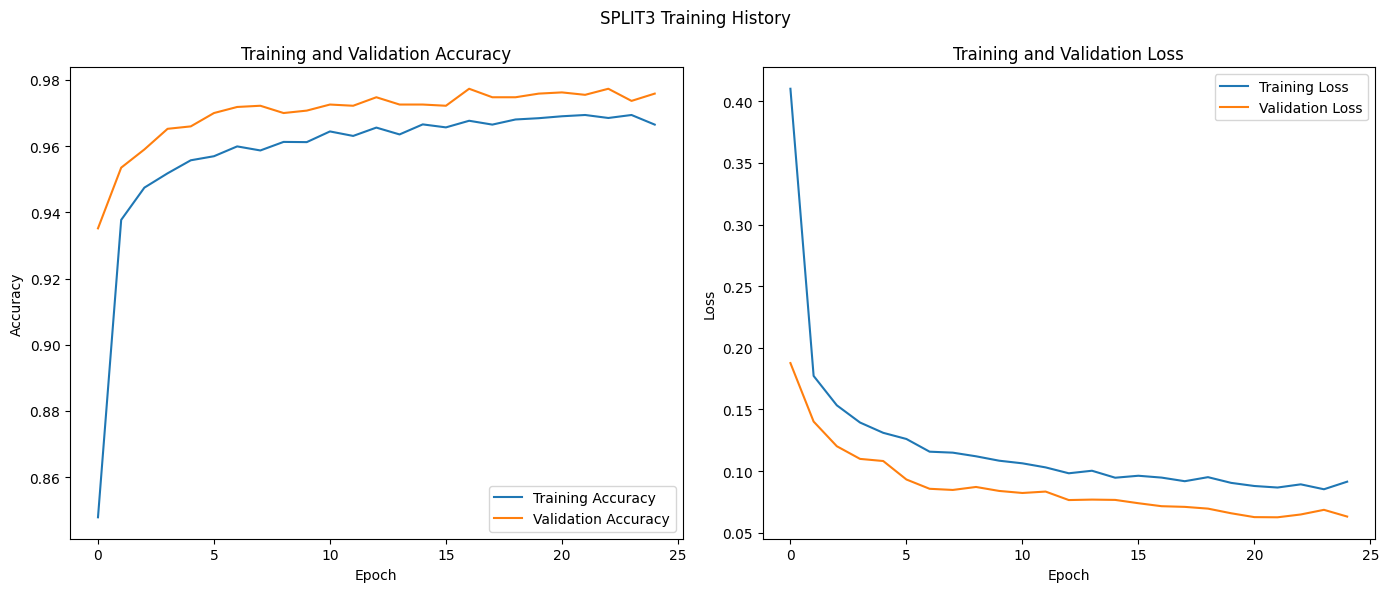

In [70]:
from helper import plot_results
plot_results(history, title="SPLIT3 Training History")

In [72]:
import tensorflow as tf

def add_fine_tuning(model, train_gen, val_gen, fine_tune_epochs=5):
    base_model = model.layers[1]  
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False
        model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
        return model.fit(
        train_gen, 
        epochs=fine_tune_epochs,
        validation_data=val_gen,
        callbacks=[checkpoint_model_fin_tuning]
)
model3 = tf.keras.models.load_model('MODEL3_V3.keras')

In [ ]:
history_phase2 = add_fine_tuning(model3, train_gen3, val_gen3, fine_tune_epochs=5)

Epoch 1/5
 13/243 ━━━━━━━━━━━━━━━━━━━━ 48s 212ms/step - accuracy: 0.7465 - loss: 0.7937